# Finish the study from existing results

Runs only what remains and assembles the figures and tables. Designed for an
unattended overnight run: **Run All Cells** does the right thing.

Order: pre-flight checks -> PySR warm-up -> improved cross-fit (parallel) ->
(optional poly / large-n) -> figure -> assembled tables.

**Before you start:** in a terminal run `caffeinate -i` (leave it open) so the
Mac does not sleep, and make sure `cf_parallel.py`, `srpds_cf.py`,
`srpds_poly.py` sit in this folder.


## Setup and run configuration


In [7]:
import os, time, pickle
import numpy as np, pandas as pd

import config as C
from dgp import DGP_REGISTRY
from estimators import SR_PDS_LOG
from simulation import run_simulation
from evaluate import evaluate
from pipeline import build_registry, run_trajectory

registry = build_registry(include_poly=True, improved_cf=True)

# --- what to run -----------------------------------------------------------
DO_CF       = True    # improved cross-fit SR-PDS (the flagship rerun)
DO_POLY2    = False   # already run -> leave off; turn on only to recompute
DO_POLY3    = False   # already run -> leave off
DO_LARGE_N  = False   # n=10,000 OG methods (~7h!). Leave off if capping at 5,000

N_JOBS_CF   = 4       # 10-core Mac: 8 workers, headroom for OS / E-cores
N_REPS_CF   = 100     # reps per design

print('methods:', list(registry.keys()))
print('results dir:', C.RESULTS_DIR.resolve())
print('toggles  CF=%s POLY2=%s POLY3=%s LARGE_N=%s' % (DO_CF, DO_POLY2, DO_POLY3, DO_LARGE_N))


methods: ['full_ols', 'pds_lasso', 'dml_lasso', 'dml_rf', 'dml_nn', 'sr_pds', 'sr_pds_cf', 'pds_poly2', 'pds_poly3']
results dir: /Users/przemekszkodon/Documents/University of Cambridge/Dissertation/repo/enriched_post_double_selection/results_full
toggles  CF=True POLY2=False POLY3=False LARGE_N=False


## Pre-flight checks

Fails loudly **now** rather than at 2 a.m. Confirms the modules import, the
results directory is writable, PySR is importable, and there is enough RAM for
the chosen worker count.


In [8]:
import importlib
ok = True
for m in ['cf_parallel','srpds_cf','srpds_poly','estimators','dgp','config','pipeline']:
    try:
        importlib.import_module(m); print(f'  module {m:<12} OK')
    except Exception as e:
        ok = False; print(f'  module {m:<12} MISSING -> {e}')

print('  results dir writable:', os.access(C.RESULTS_DIR, os.W_OK))
print('  logical cores:', os.cpu_count())
try:
    import psutil
    avail = psutil.virtual_memory().available/1e9
    print(f'  RAM available: {avail:.0f} GB')
    if avail < 12 and N_JOBS_CF > 4:
        print(f'  WARNING: low RAM for {N_JOBS_CF} workers -> consider N_JOBS_CF = 4')
except ImportError:
    print('  (install psutil to see RAM)')
try:
    from pysr import PySRRegressor; print('  pysr import: OK')
except Exception as e:
    ok = False; print('  pysr import: FAIL ->', e)

print('\nPRE-FLIGHT:', 'PASS' if ok else 'FAIL - fix the above before running overnight')


  module cf_parallel  OK
  module srpds_cf     OK
  module srpds_poly   OK
  module estimators   OK
  module dgp          OK
  module config       OK
  module pipeline     OK
  results dir writable: True
  logical cores: 10
  RAM available: 4 GB
  pysr import: OK

PRE-FLIGHT: PASS


## PySR warm-up

Compiles PySR's Julia backend once in the main process, so the parallel workers
load the cached build instead of all precompiling at once (which can race and
fail). Takes a minute or two the first time; harmless to re-run.


In [9]:
from estimators import _run_pysr
t = time.time()
_Xw = np.random.RandomState(0).randn(50, 3)
_yw = _Xw[:, 0] * _Xw[:, 1] + 0.1 * np.random.RandomState(1).randn(50)
_ = _run_pysr(_Xw, _yw, ['x0','x1','x2'], 0.01, niterations=5)
print(f'PySR warm-up done in {time.time()-t:.0f}s -- Julia is now precompiled')


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


PySR warm-up done in 1s -- Julia is now precompiled


## Task 1 - Improved cross-fit SR-PDS (parallel)

Reps run in parallel across cores (progress bar shows them completing). Heavy
PySR budget (K=10, niter=100) only on the severe design `dgp7`; cheap elsewhere.
Severe runs first, saves after each design, and **resumes** (skips designs
already in `cf_improved.pkl`) if restarted. Writes `cf_summary.csv`.


In [10]:
if DO_CF:
    from cf_parallel import run_cf_parallel
    CUBIC_D = ('cubic', 0, 1)
    CF_PER_DGP = {
        'dgp7': {'n_folds': 10, 'niterations': 100, 'parsimony_d': 0.0035},
        'dgp6': {'n_folds': 5,  'niterations': 40,  'parsimony_d': 0.01},
        'dgp8': {'n_folds': 5,  'niterations': 40,  'parsimony_d': 0.01},
    }
    DGP_ORDER = ['dgp7', 'dgp6', 'dgp8']
    CF_PKL = C.RESULTS_DIR / 'cf_improved.pkl'

    if CF_PKL.exists():
        prev = pd.read_pickle(CF_PKL); done = set(prev['dgp'].unique()); all_reps = [prev]
        print('resuming; designs already done:', sorted(done))
    else:
        done, all_reps = set(), []

    def _summarise(df, k):
        ok = df[~df['failed']]
        cov  = ((ok['ci_low'] < C.BETA0) & (C.BETA0 < ok['ci_high'])).mean()
        bias = ok['beta_hat'].mean() - C.BETA0
        rmse = np.sqrt(((ok['beta_hat'] - C.BETA0) ** 2).mean())
        rec  = (np.mean([CUBIC_D in t for t in ok['pre_lasso_terms_d']])
                if 'pre_lasso_terms_d' in ok and len(ok) else np.nan)
        return {'dgp': k, 'coverage': round(cov,3), 'bias': round(bias,3),
                'rmse': round(rmse,3), 'cubic_rec_d': round(rec,3), 'n_ok': len(ok)}

    print(f'running CF on {N_JOBS_CF} cores, {N_REPS_CF} reps/design')
    t0 = time.time()
    for dgp_key in DGP_ORDER:
        if dgp_key in done:
            continue
        cfg = CF_PER_DGP[dgp_key]
        print(f'\n=== {dgp_key} ({DGP_REGISTRY[dgp_key]["label"]})  cfg={cfg} ===', flush=True)
        df = run_cf_parallel(DGP_REGISTRY[dgp_key]['fn'], n_reps=N_REPS_CF,
                             n=C.N_HEADLINE, p=C.P, s=C.S, beta0=C.BETA0,
                             cf_config=cfg, n_jobs=N_JOBS_CF, desc=dgp_key)
        df['dgp']=dgp_key; df['estimator']='sr_pds_cf'
        df['dgp_label']=DGP_REGISTRY[dgp_key]['label']; df['est_label']='SR-PDS (CF)'
        df['beta0']=C.BETA0
        all_reps.append(df)
        pd.concat(all_reps, ignore_index=True).to_pickle(CF_PKL)
        s = _summarise(df, dgp_key)
        print(f'  coverage={s["coverage"]:.3f}  bias={s["bias"]:+.3f}  '
              f'cubic_rec_d={s["cubic_rec_d"]:.2f}  [{(time.time()-t0)/60:.1f} min]', flush=True)

    cf_improved = pd.concat(all_reps, ignore_index=True)
    cf_summary = pd.DataFrame([_summarise(cf_improved[cf_improved['dgp']==k], k)
                               for k in cf_improved['dgp'].unique()])
    cf_summary.to_csv(C.RESULTS_DIR / 'cf_summary.csv', index=False)
    print('\nCF done -> cf_improved.pkl, cf_summary.csv')
    display(cf_summary)
else:
    print('DO_CF is False -- skipping')


running CF on 4 cores, 100 reps/design

=== dgp7 (NL + severe NL conf.)  cfg={'n_folds': 10, 'niterations': 100, 'parsimony_d': 0.0035} ===
  [dgp7] 100/100 reps  ( 0.7/min,  0.0 min left)    
  coverage=0.910  bias=+0.040  cubic_rec_d=1.00  [145.9 min]

=== dgp6 (NL + mild NL conf.)  cfg={'n_folds': 5, 'niterations': 40, 'parsimony_d': 0.01} ===
  [dgp6] 100/100 reps  ( 3.8/min,  0.0 min left)    
  coverage=0.870  bias=+0.087  cubic_rec_d=0.07  [172.5 min]

=== dgp8 (Weak NL conf. (dummies))  cfg={'n_folds': 5, 'niterations': 40, 'parsimony_d': 0.01} ===
  [dgp8] 100/100 reps  ( 3.8/min,  0.0 min left)    
  coverage=0.900  bias=+0.085  cubic_rec_d=0.04  [199.1 min]

CF done -> cf_improved.pkl, cf_summary.csv


,dgp,coverage,bias,rmse,cubic_rec_d,n_ok
0,dgp7,0.91,0.040,0.178,1.00,100
1,dgp6,0.87,0.087,0.265,0.07,100
2,dgp8,0.90,0.085,0.307,0.04,100


/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
/Users/przemekszkodon/miniconda3/envs/epds/lib/python3.11/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-d

Completing DGP 1,2,3,4,5

In [ ]:
import os, pandas as pd, numpy as np, time
from cf_parallel import run_cf_parallel

EASY = ['dgp1','dgp2','dgp3','dgp4','dgp5']
CFG_EASY = {'n_folds': 5, 'niterations': 40, 'parsimony_d': 0.01}
CF_PKL = C.RESULTS_DIR / 'cf_improved.pkl'

prev = pd.read_pickle(CF_PKL) # the dgp6/7/8 results you already have
done = set(prev['dgp'].unique())
rows = [prev]
t0 = time.time()
for k in EASY:
    if k in done:
        continue
    print(f'\n=== {k} ===', flush=True)
    df = run_cf_parallel(DGP_REGISTRY[k]['fn'], n_reps=N_REPS_CF,
                         n=C.N_HEADLINE, p=C.P, s=C.S, beta0=C.BETA0,
                         cf_config=CFG_EASY, n_jobs=N_JOBS_CF, desc=k)
    df['dgp']=k; df['estimator']='sr_pds_cf'
    df['dgp_label']=DGP_REGISTRY[k]['label']; df['est_label']='SR-PDS (CF)'
    df['beta0']=C.BETA0
    rows.append(df)
    pd.concat(rows, ignore_index=True).to_pickle(CF_PKL)   # cache after each
print(f'\neasy-design CF done in {(time.time()-t0)/60:.1f} min')

## Task 2 - Degree-2 baseline (optional)

Only runs if `DO_POLY2 = True`. Leave off if `pds_poly2_*` already exist.


In [11]:
if DO_POLY2:
    rows = []
    for dgp_key in DGP_REGISTRY:
        df = run_simulation(DGP_REGISTRY[dgp_key]['fn'], registry['pds_poly2']['fn'],
                            estimator_key='pds_poly2', dgp_key=dgp_key,
                            n=C.N_HEADLINE, p=C.P, s=C.S, beta0=C.BETA0,
                            n_reps=C.N_REPS_MAIN, n_jobs=C.N_JOBS)
        m = evaluate(df, C.BETA0)
        m.update({'dgp':dgp_key,'estimator':'pds_poly2','est_label':'PDS-LASSO (poly-2)'})
        rows.append(m); print(f'  poly2 {dgp_key}: bias={m["bias"]:+.3f}', flush=True)
    pd.DataFrame(rows).to_csv(C.RESULTS_DIR/'pds_poly2_fixedn.csv', index=False)
    run_trajectory(DGP_REGISTRY, registry, ['pds_poly2'], C.CONF_DGPS,
                   n_grid=C.N_GRID_TRAJ, n_reps=C.N_REPS_TRAJ,
                   beta0=C.BETA0, p=C.P, s=C.S, n_jobs=C.N_JOBS,
                   save_path=C.RESULTS_DIR/'pds_poly2_trajectory.pkl')
else:
    print('DO_POLY2 is False -- skipping (using existing pds_poly2 files)')


DO_POLY2 is False -- skipping (using existing pds_poly2 files)


## Task 3 - Degree-3 baseline (optional)

Only runs if `DO_POLY3 = True`. Memory-heavy; serial.


In [12]:
if DO_POLY3:
    run_trajectory(DGP_REGISTRY, registry, ['pds_poly3'], C.CONF_DGPS,
                   n_grid=[30,50,100,200,500,1000,2000], n_reps=C.N_REPS_TRAJ,
                   beta0=C.BETA0, p=C.P, s=C.S, n_jobs=1,
                   save_path=C.RESULTS_DIR/'pds_poly3_trajectory.pkl')
else:
    print('DO_POLY3 is False -- skipping (using existing pds_poly3 files)')


DO_POLY3 is False -- skipping (using existing pds_poly3 files)


## Task 4 - n = 10,000 for the original methods (optional, ~7h)

Only runs if `DO_LARGE_N = True`. This is the long one (neural-net + PySR fits
at n=10,000). Leave off if the figure is capped at 5,000. Resumes if restarted.


In [13]:
"""

if DO_LARGE_N:
    keys = ['full_ols','pds_lasso','dml_lasso','dml_rf','dml_nn','sr_pds']
    run_trajectory(DGP_REGISTRY, registry, keys, ['dgp1']+C.CONF_DGPS,
                   n_grid=[10000], n_reps=C.N_REPS_TRAJ,
                   beta0=C.BETA0, p=C.P, s=C.S, n_jobs=C.N_JOBS,
                   save_path=C.RESULTS_DIR/'large_n.pkl')
else:
    print('DO_LARGE_N is False -- skipping (figure capped at 5,000)')

"""

"\n\nif DO_LARGE_N:\n    keys = ['full_ols','pds_lasso','dml_lasso','dml_rf','dml_nn','sr_pds']\n    run_trajectory(DGP_REGISTRY, registry, keys, ['dgp1']+C.CONF_DGPS,\n                   n_grid=[10000], n_reps=C.N_REPS_TRAJ,\n                   beta0=C.BETA0, p=C.P, s=C.S, n_jobs=C.N_JOBS,\n                   save_path=C.RESULTS_DIR/'large_n.pkl')\nelse:\n    print('DO_LARGE_N is False -- skipping (figure capped at 5,000)')\n\n"

## Task 5 - Trajectory figure

Figure 1: bias and RMSE vs n for the three confounding designs, every method
plus the polynomial baselines, SR-PDS in black. Reads whatever is on disk
(rep-level pickles or aggregated CSVs, plus large-n if present). Shows inline
and saves to `figures/`. Set `NMAX = 10000` only if Task 4 ran.


methods on figure: ['DML-LASSO', 'DML-NN', 'DML-RF', 'Full OLS', 'PDS-LASSO', 'PDS-LASSO (poly-2)', 'PDS-LASSO (poly-3)', 'SR-PDS']


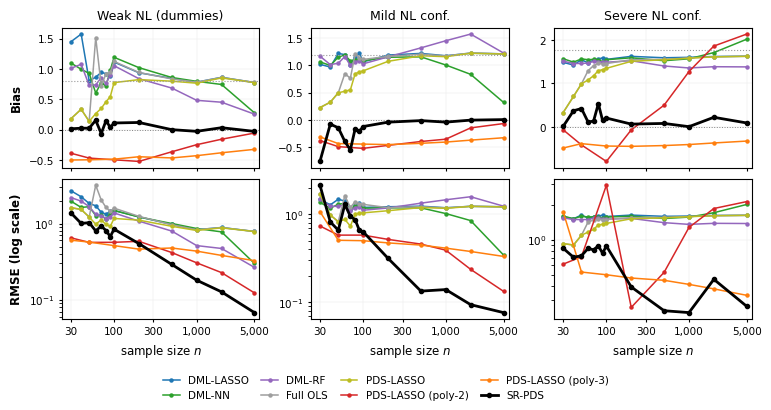

saved -> figures/n_trajectory_confounding.png


In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
RD, NMAX = C.RESULTS_DIR, 5000

def _agg_og():
    frames = [pd.read_pickle(RD/f) for f in ('trajectory.pkl','large_n.pkl') if (RD/f).exists()]
    if not frames: return pd.DataFrame(columns=['dgp','est_label','n_grid','bias','rmse'])
    d = pd.concat(frames, ignore_index=True)
    d = d[~d['failed'].astype(bool)].copy(); d['err'] = d['beta_hat'] - d['beta0']
    return (d.groupby(['dgp','est_label','n_grid'], as_index=False)
              .agg(bias=('err','mean'), rmse=('err', lambda e: np.sqrt(np.mean(e**2)))))

def _agg_poly(stem, label):
    pkl, csv = RD/f'{stem}.pkl', RD/f'{stem}.csv'
    if pkl.exists():
        d = pd.read_pickle(pkl); d = d[~d['failed'].astype(bool)].copy()
        d['err'] = d['beta_hat'] - d['beta0']
        a = (d.groupby(['dgp','n_grid'], as_index=False)
               .agg(bias=('err','mean'), rmse=('err', lambda e: np.sqrt(np.mean(e**2)))))
    elif csv.exists():
        a = pd.read_csv(csv).rename(columns={'n':'n_grid'})[['dgp','n_grid','bias','rmse']].copy()
    else:
        return None
    a['est_label'] = label; return a

agg = _agg_og()
for stem, lab in [('pds_poly2_trajectory','PDS-LASSO (poly-2)'),
                  ('pds_poly3_trajectory','PDS-LASSO (poly-3)')]:
    a = _agg_poly(stem, lab)
    if a is not None: agg = pd.concat([agg, a], ignore_index=True)
agg = agg[agg['n_grid'] <= NMAX]
print('methods on figure:', sorted(agg['est_label'].unique()))

KEEP = {'dgp8':('Weak NL (dummies)',0.80),'dgp6':('Mild NL conf.',1.20),'dgp7':('Severe NL conf.',1.77)}
COLORS = {'Full OLS':'#9e9e9e','PDS-LASSO':'#bcbd22','DML-LASSO':'#1f77b4','DML-RF':'#9467bd',
          'DML-NN':'#2ca02c','SR-PDS':'#000000','PDS-LASSO (poly-2)':'#d62728','PDS-LASSO (poly-3)':'#ff7f0e'}
NTICKS = [n for n in [30,100,300,1000,5000,10000] if n <= NMAX]
is_sr = lambda l: 'sr' in l.lower() and 'pds' in l.lower()
methods = sorted(agg['est_label'].unique(), key=lambda l: (is_sr(l), l))
cols = [c for c in KEEP if c in set(agg['dgp'])]

with plt.rc_context({'font.size':8.5,'axes.titlesize':9,'axes.labelsize':8.5,
                     'legend.fontsize':7.5,'xtick.labelsize':7.5,'ytick.labelsize':7.5}):
    fig, axes = plt.subplots(2, len(cols), figsize=(7.6,4.0), squeeze=False, constrained_layout=True)
    for c, code_ in enumerate(cols):
        title, eb = KEEP[code_]; sub = agg[agg['dgp']==code_]
        ax_b, ax_r = axes[0,c], axes[1,c]
        for m in methods:
            dm = sub[sub['est_label']==m].sort_values('n_grid')
            if dm.empty: continue
            hero = is_sr(m)
            st = dict(color=COLORS.get(m,'#777'), lw=2.0 if hero else 1.1,
                      marker='o', ms=3 if hero else 2.2, zorder=5 if hero else 2)
            ax_b.plot(dm['n_grid'], dm['bias'], label=m, **st)
            ax_r.plot(dm['n_grid'], dm['rmse'], label=m, **st)
        ax_b.axhline(0.0, ls=':', lw=0.7, color='0.5')
        if eb is not None: ax_b.axhline(eb, ls=':', lw=0.8, color='0.6')
        ax_b.set_title(title)
        for ax in (ax_b, ax_r):
            ax.set_xscale('log'); ax.set_xlim(right=NMAX*1.15)
            ax.xaxis.set_major_locator(FixedLocator(NTICKS))
            ax.xaxis.set_major_formatter(FixedFormatter([f'{v:,}' for v in NTICKS]))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.grid(True, which='major', ls='-', lw=0.3, color='0.9'); ax.tick_params(length=2)
        ax_b.tick_params(labelbottom=False)
        ax_r.set_yscale('log'); ax_r.set_xlabel('sample size $n$')
    axes[0,0].set_ylabel('Bias', fontweight='bold')
    axes[1,0].set_ylabel('RMSE (log scale)', fontweight='bold')
    handles, lbls = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='outside lower center', ncol=4, frameon=False,
               handlelength=1.6, columnspacing=1.2)
    C.FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(C.FIG_DIR/'n_trajectory_confounding.png', dpi=300, bbox_inches='tight')
    plt.show()
print('saved ->', C.FIG_DIR/'n_trajectory_confounding.png')


## Task 6 - Assemble fixed-n tables (read-only)

Folds the improved CF coverage and the poly-2 column into the headline metrics,
so Tables 3-5 are ready. Reads existing files only; computes nothing.


In [15]:
frames = []
hm = C.RESULTS_DIR/'headline_metrics.csv'
if hm.exists():
    base = pd.read_csv(hm)
    base = base[base['estimator'] != 'sr_pds_cf']   # drop old CF, replace below
    frames.append(base)

# improved CF: collapse the rep-level cache to metric rows
cfp = C.RESULTS_DIR/'cf_improved.pkl'
if cfp.exists():
    cf = pd.read_pickle(cfp)
    for k, g in cf.groupby('dgp'):
        m = evaluate(g, C.BETA0)
        m.update({'dgp':k,'estimator':'sr_pds_cf','est_label':'SR-PDS (CF)',
                  'dgp_label':DGP_REGISTRY[k]['label']})
        frames.append(pd.DataFrame([m]))

# poly-2 fixed-n
p2 = C.RESULTS_DIR/'pds_poly2_fixedn.csv'
if p2.exists():
    frames.append(pd.read_csv(p2))

if frames:
    combined = pd.concat(frames, ignore_index=True)
    combined.to_csv(C.RESULTS_DIR/'all_metrics_final.csv', index=False)
    print('wrote all_metrics_final.csv')
    for metric in ('bias','coverage'):
        print(f'\n{metric.upper()}')
        print(combined.pivot_table(index='dgp', columns='est_label', values=metric).round(3).to_string())
else:
    print('no metric files found to assemble')


wrote all_metrics_final.csv

BIAS
est_label  DML-LASSO  DML-NN  DML-RF  Full OLS  PDS-LASSO  SR-PDS  SR-PDS (CF)
dgp                                                                           
dgp1           0.001   0.088  -0.011     0.001      0.000   0.000          NaN
dgp2           0.000   0.038  -0.002    -0.000     -0.016  -0.010          NaN
dgp3          -0.006   0.097  -0.012    -0.008     -0.028  -0.007          NaN
dgp4           0.026   0.165   0.007     0.029      0.013  -0.014          NaN
dgp5           0.020   0.205  -0.125     0.029      0.014  -0.017          NaN
dgp6           1.215   1.133   1.320     1.200      1.173  -0.025        0.087
dgp7           1.631   1.568   1.443     1.598      1.589   0.110        0.040
dgp8           0.782   0.790   0.623     0.770      0.736  -0.013        0.085

COVERAGE
est_label  DML-LASSO  DML-NN  DML-RF  Full OLS  PDS-LASSO  SR-PDS  SR-PDS (CF)
dgp                                                                           
dgp1    

## Task 7 - Polynomial recovery rates

Does the polynomial basis actually *select* the confounder it contains? Cheap
(LASSO only, no PySR). For each confounding design and the degree-2 / degree-3
baselines, reports how often each true propensity term is **representable** in
the basis and **selected** by PDS-LASSO. The headline contrast: degree-2 cannot
represent the cubic on `dgp7` (0%), degree-3 can. Saves `poly_recovery.csv`.


In [17]:
from srpds_poly import poly_selection

POLY_REC_REPS = 100                 # cheap; LASSO only
POLY_REC_DGPS = C.CONF_DGPS         # dgp6 / dgp7 / dgp8
DEGREES = [2, 3]

rec_rows = []
for dgp_key in POLY_REC_DGPS:
    e = DGP_REGISTRY[dgp_key]
    terms = e['truth_terms_d']      # propensity confounders are the ones that matter
    for deg in DEGREES:
        acc = {t: {'representable': [], 'selected': []} for t in terms}
        for seed in range(POLY_REC_REPS):
            X, d, y, _ = e['fn'](n=C.N_HEADLINE, p=C.P, s=C.S, beta0=C.BETA0, seed=seed)
            sel = poly_selection(X, d, y, C.N_HEADLINE, deg, terms)
            for t in terms:
                acc[t]['representable'].append(sel[t]['representable'])
                acc[t]['selected'].append(sel[t]['selected'])
        for t in terms:
            rec_rows.append({
                'dgp': dgp_key, 'degree': deg, 'term': str(t),
                'representable': round(float(np.mean(acc[t]['representable'])), 3),
                'selected':      round(float(np.mean(acc[t]['selected'])), 3),
            })
        print(f'  {dgp_key} degree-{deg} done', flush=True)

poly_recovery = pd.DataFrame(rec_rows)
poly_recovery.to_csv(C.RESULTS_DIR / 'poly_recovery.csv', index=False)
print('\nwrote poly_recovery.csv')
poly_recovery


ImportError: cannot import name 'poly_selection' from 'srpds_poly' (/Users/przemekszkodon/Documents/University of Cambridge/Dissertation/repo/enriched_post_double_selection/main/srpds_poly.py)

## Done

In the morning you should have: `cf_improved.pkl` + `cf_summary.csv` (improved CF
coverage), `figures/n_trajectory_confounding.png` (Figure 1), and
`all_metrics_final.csv` (Tables 3-5 with the new CF and poly-2 columns).
